In [9]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imu.SO3 import SO3
from imu.SensorUtils import SensorUtils
from imu.RotationUtils import RotationUtils
np.set_printoptions(suppress=True, precision=2)

In [10]:
data = pd.read_csv('data/imu_noise_xyz.csv')

ts = data['ts'].values/1000
euler_gt = data[['euler_x', 'euler_y', 'euler_z']].values
acc = data[['accelerometer_x', 'accelerometer_y', 'accelerometer_z']].values
mag = data[['magnetometer_x', 'magnetometer_y', 'magnetometer_z']].values
gyro = data[['gyroscope_x', 'gyroscope_y', 'gyroscope_z']].values

In [11]:
acc_si = SensorUtils.cvt_acc_si(acc) # m/s^2
mag_si = SensorUtils.cvt_mag_si(mag) # uT
gyro_si = SensorUtils.cvt_gyro_si(gyro) # rad/s
N = acc.shape[0]

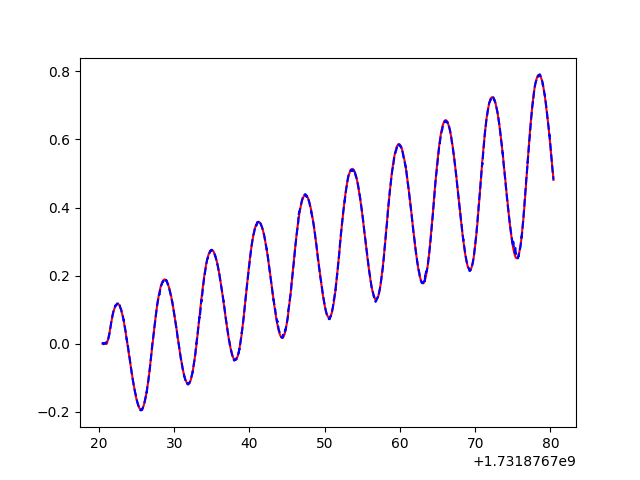

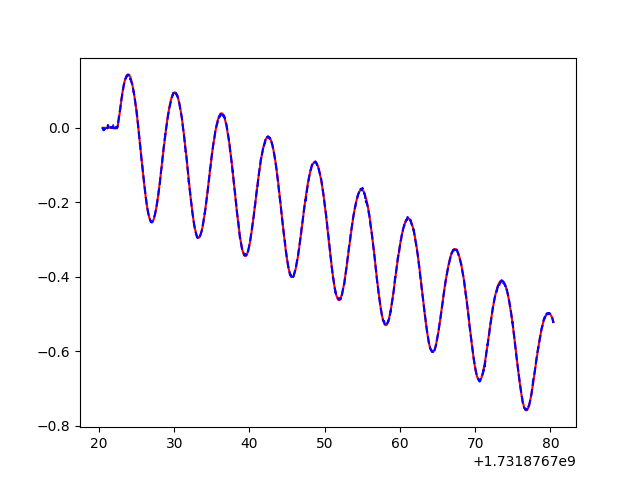

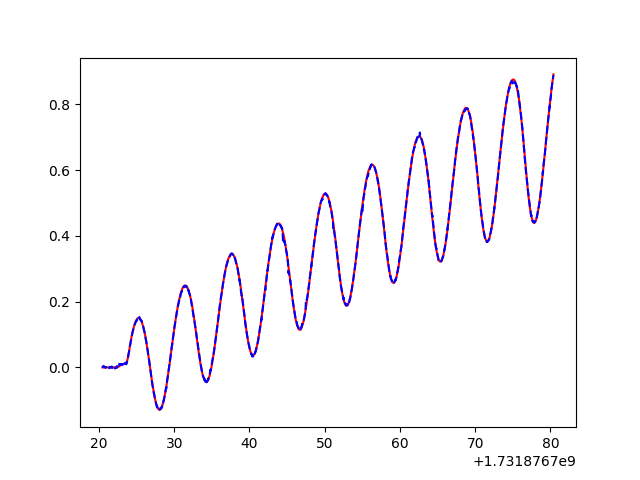

In [12]:
def orthonormalization(R):
    error = np.dot(R[:,0], R[:,1]) 
    # orthogonalization
    R0 = R[:,0] - error/2*R[:,1]
    R1 = R[:,1] - error/2*R[:,0]
    R2 = np.cross(R0, R1)
    # renormalization
    R[:,0] = 0.5*(3 - np.dot(R0, R0))*R0
    R[:,1] = 0.5*(3 - np.dot(R1, R1))*R1
    R[:,2] = 0.5*(3 - np.dot(R2, R2))*R2
    return R

R_b2g = np.eye(3)
prev_ts = 0
eul_est = np.zeros((N, 3))

kp = 0.15

for i in range(N):
    # ========================
    # dt update
    curr_ts = ts[i]
    if (prev_ts ==0):
        prev_ts = curr_ts
        continue
    dt = curr_ts - prev_ts
    prev_ts = curr_ts
    #=========================
    
    # ========================
    # gyro integration/ prediciton step
    omega = gyro_si[i]
    R_b2g = SO3.get_nextR(R_b2g, omega, dt)
    R_b2g = orthonormalization(R_b2g)
    #=========================

    # ========================
    # acc based error measurement
    acc_bdy = acc_si[i]/9.81    
    g = np.array([0, 0, -1])
    acc_gnd = R_b2g @ acc_bdy
    err_gnd_acc = np.cross(acc_gnd, g)
    # ========================

    # ========================
    # mag based error measurement
    mag_bdy = mag_si[i]/np.linalg.norm(mag_si[i])
    mag_true = np.array([1, 0, 0])
    mag_gnd = R_b2g @ mag_bdy
    mag_gnd[2] = 0
    err_gnd_mag = np.cross(mag_gnd, mag_true)
    # ========================


    # ========================
    # total error measurement
    err_gnd = err_gnd_acc + err_gnd_mag
    err_bdy = R_b2g.T @ err_gnd
    # ========================

    # ========================
    # correction step
    dR_err = SO3.get_dR(err_bdy, kp)
    R_b2g = R_b2g @ dR_err
    # ========================


    eul_est[i] = RotationUtils.rotm2eul(R_b2g)


plt.figure()
plt.plot(ts, euler_gt[:,0] * np.pi/180, 'r')
plt.plot(ts, eul_est[:,0], 'b--')

plt.figure()
plt.plot(ts, euler_gt[:,1] * np.pi/180, 'r')
plt.plot(ts, eul_est[:,1], 'b--')

plt.figure()
plt.plot(ts, euler_gt[:,2] * np.pi/180, 'r')
plt.plot(ts, eul_est[:,2], 'b--')


